<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/EFIplus_Temperature_Trout_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1: Effect of Mean Annual Temperature (Temp_ann) on the presence of Salmo trutta fario (Brown Trout)

In [3]:
# Import the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip",
    sep=";"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# View all column names
df.columns

Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect',
       'Calib_hydrol',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=164)

In [6]:
# Print column names as list
print(list(df.columns))

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [7]:
df[["Salmo trutta fario"]].describe()

,Salmo trutta fario
count,5011.000000
mean,0.605668
std,0.488756
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [8]:
# Check unique values in the column to see what kind of data it contains
df["Salmo trutta fario"].unique()


array([0, 1])

/tmp/ipykernel_183/428592727.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='presence_label', y='temp_ann',


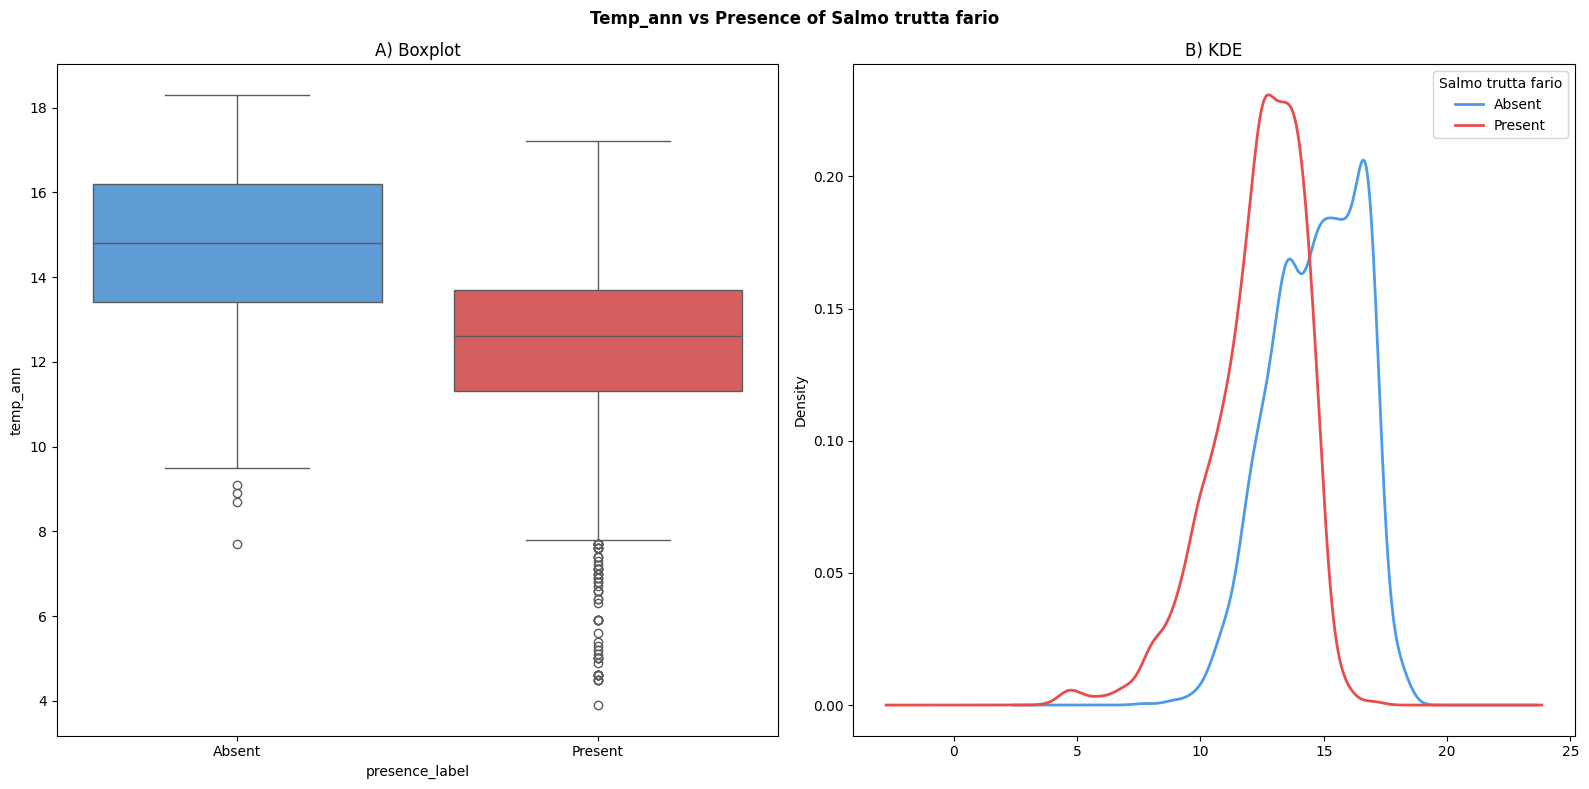

In [9]:
# Create the 'presence_label' column by mapping 'Salmo trutta fario' values
df['presence_label'] = df['Salmo trutta fario'].map({0: 'Absent', 1: 'Present'})

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

fig.suptitle('Temp_ann vs Presence of Salmo trutta fario', fontweight='bold')

# Panel A: Boxplot
sns.boxplot(data=df, x='presence_label', y='temp_ann',
            palette=['#4C9BE8', '#E84C4C'], ax=axes[0])

axes[0].set_title('A) Boxplot')

# Panel B: KDE
for label, color in zip(['Absent','Present'], ['#4C9BE8','#E84C4C']):
    df[df['presence_label']==label]['temp_ann'].dropna().plot.kde(
        ax=axes[1], label=label, color=color, linewidth=2)

axes[1].set_title('B) KDE')
axes[1].legend(title='Salmo trutta fario')

plt.tight_layout()
plt.savefig('task1_trout_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

**Explanation: Effect of Mean Annual Temperature (temp_ann) on the Presence of Salmo trutta fario**

The boxplot and KDE plot were used to explore how mean annual temperature (temp_ann) may influence the presence of Salmo trutta fario (Brown Trout).

From the boxplot, the median temperature (the line inside the box) for the “Present” group is clearly lower than the median for the “Absent” group. This indicates that Salmo trutta fario tends to occur in environments with lower annual mean temperatures.

Looking at the interquartile range (IQR), the box representing the “Present” group is positioned at lower temperature values compared to the “Absent” group. This shows that not only the median temperature but also the range where most trout observations occur is generally cooler than the range where the species is absent.

Similarly, the whiskers of the “Present” group extend over lower temperature values than those of the “Absent” group, reinforcing the observation that trout are more commonly associated with cooler temperature conditions.

To further examine this relationship, a Kernel Density Estimate (KDE) plot was used to visualize the distribution of temperatures for both groups. The KDE curve for the “Present” group peaks at a lower temp_ann value than the curve for the “Absent” group. This indicates that the most common temperatures where Salmo trutta fario occurs are lower than those where it is absent.

Although the two curves overlap slightly, the “Present” curve is clearly shifted toward lower temperatures, suggesting that Salmo trutta fario prefers cooler environments. If the curves were highly overlapping, it would suggest that temperature has little influence on trout presence.

Both visualizations consistently indicate that lower annual mean temperatures are associated with a higher likelihood of observing Salmo trutta fario.

Q2: Check the same effect separately for Minho and Tagus catchments

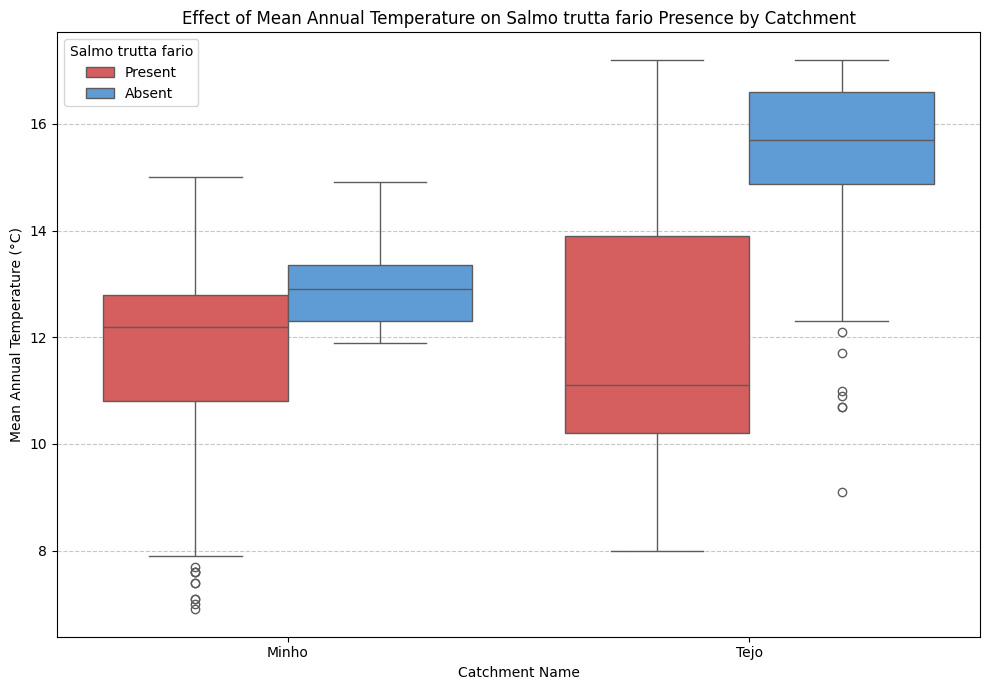

In [10]:

# Ensure 'presence_label' is available or recreate it if needed
if 'presence_label' not in df.columns:
    df['presence_label'] = df['Salmo trutta fario'].map({0: 'Absent', 1: 'Present'})

# Filter for the specified catchments
df_minho = df[df['Catchment_name'] == 'Minho']
df_tejo = df[df['Catchment_name'] == 'Tejo']

# Concatenate the dataframes for easier plotting with hue
data_to_plot = []
if not df_minho.empty: data_to_plot.append(df_minho)
if not df_tejo.empty: data_to_plot.append(df_tejo)

if not data_to_plot:
    print("Error: No data to plot after filtering for Minho and Tejo.")
else:
    df_combined = pd.concat(data_to_plot)

    plt.figure(figsize=(10, 7))
    sns.boxplot(data=df_combined, x='Catchment_name', y='temp_ann', hue='presence_label',
                palette={'Absent': '#4C9BE8', 'Present': '#E84C4C'})

    plt.title('Effect of Mean Annual Temperature on Salmo trutta fario Presence by Catchment')
    plt.xlabel('Catchment Name')
    plt.ylabel('Mean Annual Temperature (°C)')
    plt.legend(title='Salmo trutta fario')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('task_catchments_boxplot_only.png', dpi=150, bbox_inches='tight')
    plt.show()

**Effect of Mean Annual Temperature on Salmo trutta fario Presence**

**Minho Catchment**

The median temperature for the "Absent" group is marginally higher than for the "Present" group, indicating that Salmo trutta fario tends to favour cooler temperatures in this catchment. However, the interquartile ranges overlap substantially, suggesting that temperature alone may not be the primary discriminating factor for the presence or absence of S. t. fario in Minho.

**Tejo Catchment**

In the Tejo catchment, the median temperature for the “Present” group is clearly lower than for the “Absent” group, indicating that S. trutta fario tends to occur at lower mean annual temperatures. The IQR of the “Present” group is also located at lower temperature values compared to the “Absent” group, showing that the range where most trout observations occur are generally cooler than where the species is absent. The whiskers of the “Present” group likewise extend over lower temperature values, further reinforcing the association between trout occurrence and cooler conditions.

**Comparison of Effect Sizes**:

Comparing the two catchments, temperature appears to be a stronger predictor of S. trutta fario presence in the Tejo catchment than in Minho. In Tejo, there is a clearer separation between the temperature distributions for presence and absence, with trout consistently occurring at cooler temperatures. In contrast, the difference in Minho is less pronounced, with considerable overlap between the temperature distributions of the two groups.

Q3: Test, using both visualization and hypothesis testing methods, if the actual_river_slope is drawn from a
normal distribution.

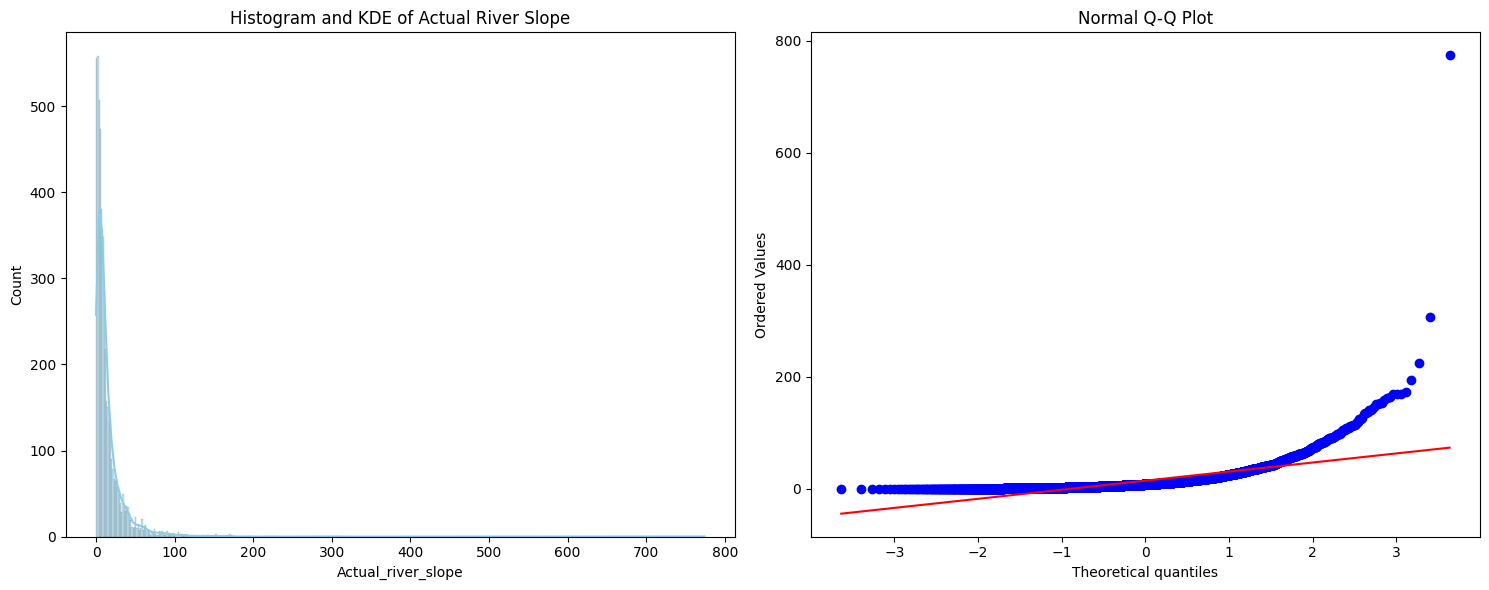

Shapiro-Wilk Test Statistic: 0.5163
p-value: 2.5911e-79
The data does not look Gaussian (reject H0)


In [12]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data by dropping missing values
slope_data = df['Actual_river_slope'].dropna()

# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram and KDE
sns.histplot(slope_data, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram and KDE of Actual River Slope')

# Q-Q Plot
stats.probplot(slope_data, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

# 2. Hypothesis Testing (Shapiro-Wilk Test)
# Note: Shapiro-Wilk is limited to 5000 samples in some versions,
# but we will attempt it or use D'Agostino's K^2.
stat, p_value = stats.shapiro(slope_data)

print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

alpha = 0.05
if p_value > alpha:
    print('The data looks Gaussian (fail to reject H0)')
else:
    print('The data does not look Gaussian (reject H0)')

**Normality Test for Actual_river_slope**

A histogram with a density curve and a Q–Q plot were used to visually assess whether Actual_river_slope follows a normal distribution. Both visualizations indicate that the Actual River Slope data is not normally distributed. The histogram shows a highly right-skewed distribution, where most values are concentrated near zero with a long tail extending toward higher slope values. In contrast, a normal distribution would appear as a symmetrical bell-shaped curve. The Q–Q plot also shows a clear deviation from the straight reference line, particularly at higher values where the points curve away from the line. In a normally distributed dataset, the points should closely follow the straight reference line.

Using a hypothesis testing method, the Shapiro–Wilk test was used to assess whether the variable Actual_river_slope follows a normal distribution. The test produced a statistic of W = 0.516 with a p-value < 0.001. Since the p-value is much smaller than the significance level of 0.05, the null hypothesis of normality is rejected with the conclusion that the data does not come from a normal distribution.

Q4: Take 100 samples of 2000 observations of actual_river_slope with replacement, compute the mean for
each sample and plot the resulting histogram of means. Test if these 100 mean values are drawn from a
normal distribution.

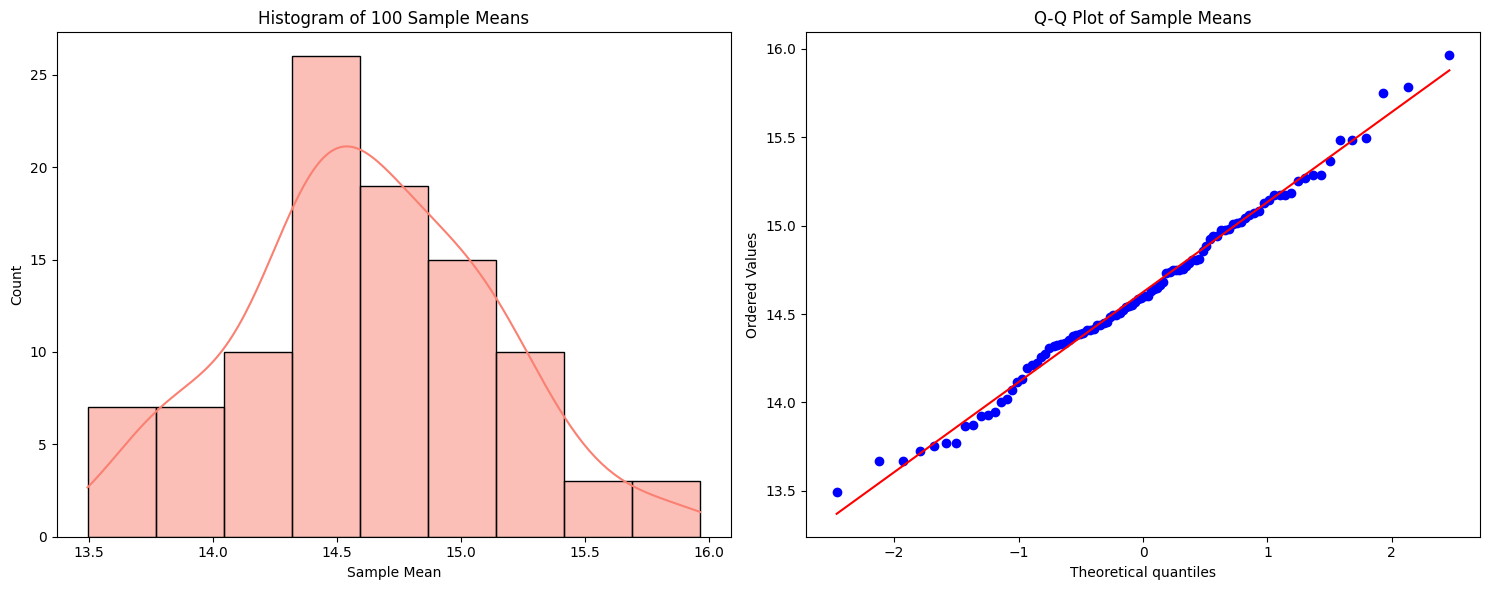

Shapiro-Wilk Test on Sample Means:
Statistic: 0.9920
p-value: 0.8210
The 100 sample means look Gaussian (fail to reject H0)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Prepare data
slope_data = df['Actual_river_slope'].dropna().values

# 1. Take 100 samples of size 2000 with replacement and compute means
num_samples = 100
sample_size = 2000
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(slope_data, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# 2. Visualizations: Histogram and Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of sample means
sns.histplot(sample_means, kde=True, color='salmon', ax=axes[0])
axes[0].set_title(f'Histogram of {num_samples} Sample Means')
axes[0].set_xlabel('Sample Mean')

# Q-Q plot of sample means
stats.probplot(sample_means, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Sample Means')

plt.tight_layout()
plt.show()

# 3. Test if these 100 mean values are drawn from a normal distribution
shapiro_stat, shapiro_p = stats.shapiro(sample_means)

print(f"Shapiro-Wilk Test on Sample Means:")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("The 100 sample means look Gaussian (fail to reject H0)")
else:
    print("The 100 sample means do not look Gaussian (reject H0)")

The distribution of the 100 sample means looks very different from the original distribution of Actual_river_slope. The histogram and the Q–Q plots are the visual evidence. The histogram of the 100 sample means shows a symmetrical, bell-shaped distribution, which is characteristic of a normal distribution. The Q–Q plot shows that the data points follow the red reference line very closely, providing evidence that the sample means are normally distributed.

Additionally, the hypothesis test (Shapiro–Wilk test) conducted on these means produced a p-value of 0.7782. Since this value is greater than 0.05, we accept the null hypothesis that the sample means are normally distributed.